# 1. Survivorship bias

**The mistake in one sentence:** you study the cases that survived, and forget the cases that did not.

Running on Google Colab? Run the next cell first. It downloads the repo so the data files are there. On your own computer you can skip it.

In [1]:
import os
from pathlib import Path
if not any((p / "src").exists() for p in [Path.cwd(), *Path.cwd().parents]):
    !git clone https://github.com/USERNAME/data-make-sins.git
    os.chdir("data-make-sins/notebooks")

In [2]:
import sys
from pathlib import Path
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.append(str(root / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
import dms

dms.style()

## The real case

In 1943, US bombers came back from missions over Europe full of bullet holes. The holes were on the wings and the tail. The plan was to add armour there.

The statistician Abraham Wald said no. These planes came home. The planes hit in the engine never came back, so nobody counted their holes. The engine needed the armour.

Below we rebuild that situation with a small simulation.

## Build the data

Five parts of a plane. Each part has a share of the surface (where bullets land) and a chance that a hit there brings the plane down.

In [3]:
rng = np.random.default_rng(7)

regions = pd.DataFrame({
    "region": ["wings", "tail", "fuselage", "engine", "cockpit"],
    "share_of_area": [0.40, 0.15, 0.30, 0.10, 0.05],
    "chance_hit_is_fatal": [0.05, 0.10, 0.10, 0.80, 0.90],
}).set_index("region")
regions

,share_of_area,chance_hit_is_fatal
region,,
wings,0.40,0.05
tail,0.15,0.10
fuselage,0.30,0.10
engine,0.10,0.80
cockpit,0.05,0.90


In [4]:
n_planes = 400
rows = []
for plane in range(n_planes):
    n_hits = rng.poisson(3)
    for region in rng.choice(regions.index, size=n_hits, p=regions.share_of_area):
        rows.append({"plane": plane, "region": region})
hits = pd.DataFrame(rows)

fatal = rng.random(len(hits)) < hits.region.map(regions.chance_hit_is_fatal)
lost_planes = set(hits.plane[fatal])
hits["plane_returned"] = ~hits.plane.isin(lost_planes)

print(f"{hits.plane.nunique()} planes were hit, {len(lost_planes)} of them were lost")
hits.head()

380 planes were hit, 173 of them were lost


,plane,region,plane_returned
0,0,engine,False
1,0,wings,False
2,0,fuselage,False
3,0,fuselage,False
4,1,wings,False


## What the army could see, and what was true

In [5]:
counts = (hits.groupby(["region", "plane_returned"]).size()
              .unstack(fill_value=0)
              .rename(columns={True: "returned", False: "lost"})
              .loc[regions.index])
counts["all planes"] = counts["returned"] + counts["lost"]
counts

plane_returned,lost,returned,all planes
region,,,
wings,229,246,475
tail,84,103,187
fuselage,157,188,345
engine,111,19,130
cockpit,60,2,62


In [6]:
share = counts[["returned", "all planes"]]
share = (share / share.sum() * 100).round(1)
share.columns = ["% of hits seen on returned planes", "% of hits on all planes"]
share

,% of hits seen on returned planes,% of hits on all planes
region,,
wings,44.1,39.6
tail,18.5,15.6
fuselage,33.7,28.8
engine,3.4,10.8
cockpit,0.4,5.2


On the returned planes, the engine and cockpit look almost untouched. On all planes they take their fair share of hits. The difference is the planes at the bottom of the sea.

In [7]:
fig, ax = plt.subplots()
x = np.arange(len(share))
ax.bar(x - 0.2, share.iloc[:, 0], width=0.4, color=dms.RED, label="hits on planes that returned")
ax.bar(x + 0.2, share.iloc[:, 1], width=0.4, color=dms.BLUE, label="hits on all planes")
ax.set_xticks(x, share.index)
ax.set_ylabel("share of hits (%)")
ax.set_title("The engine looks safe only because hit planes never came back")
ax.legend()
dms.save(fig, "01_survivorship.png")
plt.show()

## Animated figure

Red dots: holes counted on the planes that came home. Blue dots: holes on the planes that were lost, which nobody could count.

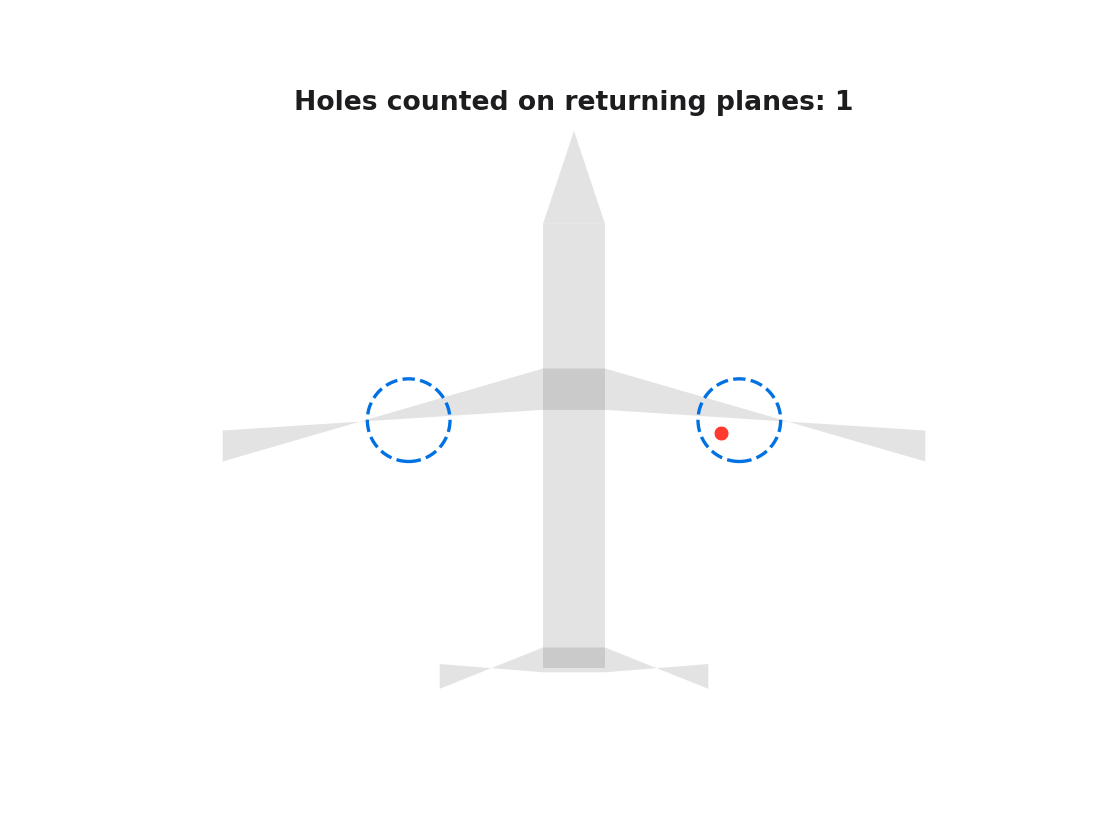

In [8]:
def random_point(region):
    if region == "wings":
        side = rng.choice([-1, 1])
        return side * rng.uniform(0.2, 1.6), rng.uniform(-0.18, 0.18)
    if region == "tail":
        return rng.uniform(-0.55, 0.55), rng.uniform(-1.28, -1.08)
    if region == "fuselage":
        return rng.uniform(-0.12, 0.12), rng.uniform(-1.0, 0.85)
    if region == "engine":
        return rng.choice([-0.8, 0.8]) + rng.uniform(-0.12, 0.12), rng.uniform(-0.12, 0.12)
    return rng.uniform(-0.1, 0.1), rng.uniform(0.95, 1.2)

returned_pts = np.array([random_point(r) for r in hits.region[hits.plane_returned].sample(80, random_state=1)])
lost_pts = np.array([random_point(r) for r in hits.region[~hits.plane_returned].sample(40, random_state=2)])

fig, ax = plt.subplots(figsize=(7, 5.2))
ax.set_xlim(-1.9, 1.9); ax.set_ylim(-1.55, 1.55); ax.set_aspect("equal"); ax.axis("off")
silhouette = dict(color=dms.INK, alpha=0.12, lw=0)
ax.add_patch(plt.Polygon([[-1.7, -0.2], [-0.15, 0.25], [0.15, 0.25], [1.7, -0.2], [1.7, -0.05], [0.15, 0.05], [-0.15, 0.05], [-1.7, -0.05]], **silhouette))
ax.add_patch(plt.Polygon([[-0.65, -1.3], [-0.15, -1.1], [0.15, -1.1], [0.65, -1.3], [0.65, -1.18], [0.15, -1.22], [-0.15, -1.22], [-0.65, -1.18]], **silhouette))
ax.add_patch(plt.Rectangle((-0.15, -1.2), 0.3, 2.15, **silhouette))
ax.add_patch(plt.Polygon([[-0.15, 0.95], [0, 1.4], [0.15, 0.95]], **silhouette))
for cx in (-0.8, 0.8):
    ax.add_patch(plt.Circle((cx, 0), 0.2, fill=False, ec=dms.BLUE, lw=1.5, ls="--"))
red = ax.scatter([], [], s=28, color=dms.RED, zorder=3)
blue = ax.scatter([], [], s=28, color=dms.BLUE, zorder=3)
title = ax.text(0, 1.5, "", ha="center", fontsize=12, weight="bold")

n_r, n_l, hold = len(returned_pts), len(lost_pts), 15

def update(i):
    if i < n_r:
        red.set_offsets(returned_pts[: i + 1])
        title.set_text(f"Holes counted on returning planes: {i + 1}")
    elif i < n_r + hold:
        title.set_text("No holes on the engines. Add armour to the wings?")
    else:
        j = min(i - n_r - hold + 1, n_l)
        blue.set_offsets(lost_pts[:j])
        title.set_text("The planes that never came back were hit here")
    return red, blue, title

anim = FuncAnimation(fig, update, frames=n_r + hold + n_l + 12, interval=120, blit=False)
gif = dms.FIG / "01_bombers.gif"
anim.save(gif, writer=PillowWriter(fps=8))
plt.close(fig)
display(Image(filename=str(gif)))

## Better method

Before you count, decide who belongs in the population. Count the planes that left, not only the planes that returned. When the missing cases are gone forever, say so, and treat every conclusion about them as a guess.

## Ask this

Who is missing from this data?